[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter8_seminar_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 8: Advanced volatility modelling

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 8; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_8'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
# local copy of the Oxford-Man realized library, if present (not distributed; read_omi downloads it)
REALIZED_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                     if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
END = '2026-09-18'          # last day of the saved data
# Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): the last public
# file (28 February 2022), preserved by the Internet Archive; six indices and the main measures
OMI_URL = ('https://web.archive.org/web/20220301022212id_/'
           'https://realized.oxford-man.ox.ac.uk/images/oxfordmanrealizedvolatilityindices.zip')
OMI_FILE = 'omi_realized_library_v03.csv'
OMI_SYMBOLS = ['.SPX', '.GDAXI', '.FTSE', '.N225', '.STOXX50E', '.FCHI']
OMI_COLS = ['rv5', 'rv5_ss', 'rv10', 'bv', 'bv_ss', 'medrv', 'rk_parzen', 'rk_twoscale', 'rsv', 'open_to_close',
            'close_price', 'open_price', 'nobs']

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_omi(symbols=None, local=True):
    """Oxford-Man Institute's realized library, version 0.3: daily realised measures (OMI_COLS) of six indices
    (OMI_SYMBOLS), columns date, symbol and the measures, sorted by symbol and date. The library is not
    redistributed with the course: a local copy data/realized/omi_realized_library_v03.csv is used if present,
    otherwise the last public file (Internet Archive copy of 28 February 2022) is downloaded once, the six indices
    are extracted and cached in the temporary folder. Cite: Heber, G., Lunde, A., Shephard, N. and Sheppard, K.
    (2009), Oxford-Man Institute's realized library, version 0.3, Oxford-Man Institute, University of Oxford."""
    import tempfile
    import zipfile
    if 'omi' not in _CACHE:
        cache = os.path.join(tempfile.gettempdir(), 'ats_omi')
        cands = ([os.path.join(REALIZED_DIR, OMI_FILE)] if (local and REALIZED_DIR) else []) + [os.path.join(cache, OMI_FILE)]
        path = next((c for c in cands if os.path.exists(c)), '')
        if not path:
            print("Downloading the Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and "
                  "Sheppard 2009), last public file of 28 February 2022, from the Internet Archive")
            os.makedirs(cache, exist_ok=True)
            zpath = os.path.join(cache, 'oxfordmanrealizedvolatilityindices.zip')
            if not os.path.exists(zpath):
                req = urllib.request.Request(OMI_URL, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=300) as r:
                    raw = r.read()
                with open(zpath, 'wb') as f:
                    f.write(raw)
            with zipfile.ZipFile(zpath) as z:
                d = pd.read_csv(z.open(z.namelist()[0]))
            d = d.rename(columns={d.columns[0]: 'date'})
            d['date'] = pd.to_datetime(d['date'].str[:10])
            d = d[d['Symbol'].isin(OMI_SYMBOLS)][['date', 'Symbol'] + OMI_COLS].rename(columns={'Symbol': 'symbol'})
            path = os.path.join(cache, OMI_FILE)
            d.sort_values(['symbol', 'date']).to_csv(path, index=False, float_format='%.6g')
        _CACHE['omi'] = pd.read_csv(path, parse_dates=['date'])
    d = _CACHE['omi']
    if symbols is not None:
        d = d[d['symbol'].isin([symbols] if isinstance(symbols, str) else list(symbols))]
    return d.copy()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Realised-measure data

- Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): daily realised measures of six equity indices, 2000-2022; the library is not redistributed with the course: `read_omi` downloads its last public file (28 February 2022) from the Internet Archive and extracts the six indices.
- Our daily realised measures of Bitcoin and Ether from Binance public one-minute prices, 2018-2026, and the one-second signature table of August 2026 (`data/realized/`).
- Variances in %^2 (returns in %).

## Seminar functions

- The GARCH, GARCH-MIDAS, jump-test and HAR tools of Chapter 8, the data loaders and the functions of the solved tasks.

In [ ]:
import time
from scipy import special
from scipy.signal import lfilter
SEED = 2026
REAL_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/realized/'
REAL_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                 if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
OMI_NAMES = {'.SPX': 'S&P 500', '.GDAXI': 'DAX', '.FTSE': 'FTSE 100', '.N225': 'Nikkei 225', '.STOXX50E': 'Euro Stoxx 50', '.FCHI': 'CAC 40'}
MU1 = np.sqrt(2 / np.pi)
HT_C = np.pi ** 2 / 4 + np.pi - 5
SIM = {'n': 23400, 'mean_iv': 1.0, 'sd_slow': 0.75, 'sd_fast': 0.45, 'hl_slow': 60.0, 'hl_fast': 2.0, 'rho': -0.6, 'lam': 0.08, 'sd_jump': 0.8, 'omega': 0.004}
HAR_WIN = 1000
GMV_ASSETS = ['AAPL.US', 'AMZN.US', 'BAC.US', 'C.US', 'GOOGL.US', 'GS.US', 'JPM.US', 'META.US', 'MS.US', 'MSFT.US', 'MSTR.US', 'NVDA.US', 'TSLA.US', 'WFC.US', 'SPY.US', 'QQQ.US', 'RSP.US']
A2J, A2I, A2T = np.array([[50.0, 40.0], [40.0, 36.0]]), np.array([[120.0, 90.0], [90.0, 72.0]]), 4000
A3 = {'iv': 1.0, 'omega2': 1.6e-05, 'n': (23400, 390, 78)}
A4 = {'rv_all': 1.75, 'rv_avg': 1.005, 'n': 23400, 'K': 300, 'H': 4}
A5R = np.array([0.1, -0.12, 0.08, 1.2, -0.09, 0.11, -0.07, 0.1])
A6 = {'alpha': 0.001, 'n': (78, 390)}
A7 = {'bd': 0.3, 'bw': 0.4, 'bm': 0.2, 'b0': 0.1}
A8 = {'var_iv': 0.8, 'var_e': 0.2, 'phi': 0.95, 'iq': (0.5, 5.0), 'n': 78}
A9 = {'c': 0.6}
A10 = {'S': [[1.0, 0.5], [0.5, 1.0]], 'a': 0.05, 'b': 0.93, 'Q': [[1.2, 0.7], [0.7, 0.9]], 'z': [1.5, -0.5]}
ETF_DATE = '2024-01-11'
from math import gamma as gamma_fn


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def read_realized(fname, **kw):
    """A file of data/realized: local copy of the course data, otherwise the ATS repository on GitHub."""
    p = os.path.join(REAL_DIR, fname) if REAL_DIR else ''
    return pd.read_csv(p if p and os.path.exists(p) else REAL_RAW + fname, **kw)


def omi(symbol='.SPX'):
    """Oxford-Man realized library v0.3 (Heber, Lunde, Shephard and Sheppard 2009): one index, daily, returns in %
    and variances in %^2; days with a non-positive measure are dropped."""
    d = read_omi()
    d = d[d['symbol'] == symbol].set_index('date').sort_index()
    out = pd.DataFrame({'rv': 1e4 * d['rv5'], 'rv_ss': 1e4 * d['rv5_ss'], 'bv': 1e4 * d['bv'],
                        'medrv': 1e4 * d['medrv'], 'rk': 1e4 * d['rk_parzen'], 'rsv': 1e4 * d['rsv'],
                        'oc': 100 * d['open_to_close'], 'nobs': d['nobs']})
    return out[(out[['rv', 'bv', 'rk', 'medrv']] > 0).all(axis=1)].dropna()


def binance_daily(coin='btc'):
    """Our daily realised measures of Bitcoin or Ether from Binance one-minute prices (UTC days, %, %^2)."""
    d = read_realized('binance_daily_realized.csv', parse_dates=['date'], index_col='date')
    c = [x for x in d.columns if x.startswith(coin + '_')]
    out = d[c].rename(columns=lambda x: x[len(coin) + 1:]).dropna()
    out = out[(out[['rv5', 'bv5', 'rk1']] > 0).all(axis=1)]
    if 'rcov5' in d.columns:
        out['rcov5'] = d['rcov5'].reindex(out.index)
    return out


def returns(name, start='2000-01-01', end=None):
    """Daily log returns in %."""
    p = load_close(name, start=start, end=end) if end else load_close(name, start=start)
    return (100 * np.log(p).diff()).dropna()


def garch_var(e, omega, alpha, beta, gamma=0.0, s0=None):
    """Conditional variances of a (GJR-)GARCH(1,1) by a linear filter:
    s_t = omega + (alpha + gamma 1[e_{t-1} < 0]) e_{t-1}^2 + beta s_{t-1}, s_1 = s0 (sample variance)."""
    e = np.asarray(e, float)
    s0 = np.var(e) if s0 is None else s0
    x = np.empty_like(e)
    x[0] = s0
    x[1:] = omega + (alpha + gamma * (e[:-1] < 0)) * e[:-1] ** 2
    return lfilter([1.0], [1.0, -beta], x)


def t_logpdf_std(z, nu):
    """Log density of a Student-t standardised to unit variance."""
    return (special.gammaln((nu + 1) / 2) - special.gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2))
            - (nu + 1) / 2 * np.log1p(z ** 2 / (nu - 2)))


def garch_lt(theta, e, dist='normal', gjr=False):
    """Per-observation log-likelihood of a (GJR-)GARCH(1,1) with Gaussian or standardised Student-t innovations."""
    omega, alpha, beta = theta[:3]
    gamma = theta[3] if gjr else 0.0
    s = garch_var(e, omega, alpha, beta, gamma)
    if dist == 'normal':
        return -0.5 * (np.log(2 * np.pi) + np.log(s) + e ** 2 / s)
    nu = theta[-1]
    return t_logpdf_std(e / np.sqrt(s), nu) - 0.5 * np.log(s)


def num_scores(f, theta, h=1e-5):
    """Numerical per-observation scores (T x k) of a per-observation log-likelihood f(theta)."""
    theta = np.asarray(theta, float)
    out = []
    for j in range(len(theta)):
        d = np.zeros_like(theta)
        d[j] = h * max(1.0, abs(theta[j]))
        out.append((f(theta + d) - f(theta - d)) / (2 * d[j]))
    return np.column_stack(out)


def num_hessian(f, theta, h=1e-4):
    """Numerical Hessian of the summed log-likelihood, from differences of the summed scores."""
    theta = np.asarray(theta, float)
    k = len(theta)
    H = np.zeros((k, k))
    for j in range(k):
        d = np.zeros(k)
        d[j] = h * max(1.0, abs(theta[j]))
        H[:, j] = (num_scores(f, theta + d).sum(0) - num_scores(f, theta - d).sum(0)) / (2 * d[j])
    return 0.5 * (H + H.T)


def sandwich(f, theta):
    """Hessian-based, outer-product and Bollerslev-Wooldridge (sandwich) standard errors."""
    S = num_scores(f, theta)
    H = num_hessian(f, theta)
    Hi = np.linalg.inv(-H)
    I = S.T @ S
    return dict(se_h=np.sqrt(np.diag(Hi)), se_opg=np.sqrt(np.diag(np.linalg.inv(I))),
                se_bw=np.sqrt(np.diag(Hi @ I @ Hi)), cov_bw=Hi @ I @ Hi)


def fit_garch(e, dist='normal', gjr=False, se=True):
    """(Q)ML of a (GJR-)GARCH(1,1) on demeaned returns e (in %)."""
    e = np.asarray(e, float)
    v = np.var(e)
    x0 = [0.05 * v, 0.08, 0.90] + ([0.05] if gjr else []) + ([8.0] if dist == 't' else [])
    bnds = [(1e-8, 10 * v), (1e-6, 0.6), (0.0, 0.9999)] + ([(-0.3, 0.6)] if gjr else []) + ([(2.2, 200)] if dist == 't' else [])

    def nll(th):
        a = th[1] + (0.5 * th[3] if gjr else 0) + th[2]
        if a >= 0.99999 or (gjr and th[1] + th[3] < 0):
            return 1e10
        val = -garch_lt(th, e, dist, gjr).sum()
        return val if np.isfinite(val) else 1e10
    best = None
    for b0 in (0.90, 0.80, 0.95):
        x = list(x0)
        x[2] = b0
        r = optimize.minimize(nll, x, method='L-BFGS-B', bounds=bnds)
        if best is None or r.fun < best.fun:
            best = r
    th = best.x
    out = dict(theta=th, ll=-best.fun, s=garch_var(e, th[0], th[1], th[2], th[3] if gjr else 0.0))
    if se:
        out.update(sandwich(lambda t: garch_lt(t, e, dist, gjr), th))
    return out


def beta_weights(K, w2):
    """Restricted beta lag polynomial of GARCH-MIDAS (w1 = 1): phi_k proportional to (1 - k/K)^(w2 - 1), k = 1..K."""
    k = np.arange(1, K + 1)
    w = (1 - k / K) ** (w2 - 1) if w2 != 1 else np.ones(K)
    w = np.where(np.isfinite(w), w, 0.0)
    return w / w.sum()


def midas_data(r, X, K=36):
    """Align daily returns with a monthly regressor: for each day, the K lagged monthly values X_{t-1}, ..., X_{t-K}."""
    m = r.index.to_period('M')
    Xp = X.copy()
    Xp.index = Xp.index.to_period('M')
    months = pd.period_range(m.min(), m.max(), freq='M')
    lags = np.full((len(months), K), np.nan)
    for i, mm in enumerate(months):
        for k in range(1, K + 1):
            lags[i, k - 1] = Xp.get(mm - k, np.nan)
    ok = ~np.isnan(lags).any(1)
    keep = set(months[ok])
    sel = np.array([p in keep for p in m])
    idx = {p: i for i, p in enumerate(months)}
    return r[sel], lags, np.array([idx[p] for p in m[sel]]), months


def gm_components(th, e, lags, mi, log_tau=True):
    """GARCH-MIDAS: tau_t (monthly) and g_{i,t} (daily) for theta = (alpha, beta, m, theta_x, w2)."""
    alpha, beta, m, thx, w2 = th
    w = beta_weights(lags.shape[1], w2)
    z = m + thx * (lags @ w)
    tau_m = np.exp(z) if log_tau else z
    tau = tau_m[mi]
    u = e ** 2 / tau
    x = np.empty_like(e)
    x[0] = 1.0
    x[1:] = (1 - alpha - beta) + alpha * u[:-1]
    g = lfilter([1.0], [1.0, -beta], x)
    return tau, g, tau_m


def gm_lt(th, e, lags, mi, log_tau=True):
    tau, g, _ = gm_components(th, e, lags, mi, log_tau)
    s = tau * g
    return -0.5 * (np.log(2 * np.pi) + np.log(s) + e ** 2 / s)


def fit_garch_midas(r, X, K=36, log_tau=True):
    """GARCH-MIDAS of Engle, Ghysels and Sohn (2013), restricted beta weights; Gaussian QML; sandwich s.e."""
    rr, lags, mi, months = midas_data(r, X, K)
    e = (rr - rr.mean()).values
    v = np.var(e)

    def nll(th):
        if th[0] <= 0 or th[1] <= 0 or th[0] + th[1] >= 0.9999 or not (1.0 <= th[4] <= 50):
            return 1e10
        tau, g, _ = gm_components(th, e, lags, mi, log_tau)
        if np.any(tau <= 0) or np.any(~np.isfinite(tau)):
            return 1e10
        val = -gm_lt(th, e, lags, mi, log_tau).sum()
        return val if np.isfinite(val) else 1e10
    best = None
    m0 = np.log(v) if log_tau else v
    for thx0 in ((-0.1, 0.1, -0.5, 0.5) if log_tau else (0.5, 0.05)):
        for w20 in (1.5, 5.0):
            r_ = optimize.minimize(nll, [0.08, 0.90, m0, thx0, w20], method='Nelder-Mead',
                                   options=dict(maxiter=8000, xatol=1e-7, fatol=1e-7))
            if best is None or r_.fun < best.fun:
                best = r_
    th = best.x
    se = sandwich(lambda t: gm_lt(t, e, lags, mi, log_tau), th)
    tau, g, tau_m = gm_components(th, e, lags, mi, log_tau)
    vr = float(np.var(np.log(tau)) / np.var(np.log(tau * g)))
    return dict(theta=th, ll=-best.fun, se=se['se_bw'], tau=pd.Series(tau, rr.index), g=pd.Series(g, rr.index),
                vr=vr, T=len(e), e=e, index=rr.index)


def bipower(r):
    """Bipower variation of the rows of r (Barndorff-Nielsen and Shephard 2004), small-sample factor n/(n-1)."""
    n = r.shape[-1]
    return MU1 ** -2 * n / (n - 1) * np.sum(np.abs(r[..., 1:]) * np.abs(r[..., :-1]), -1)


def tripower(r):
    """Realised tripower quarticity, an estimator of the integrated quarticity robust to jumps."""
    from math import gamma
    mu43 = 2 ** (2 / 3) * gamma(7 / 6) / gamma(1 / 2)
    n = r.shape[-1]
    a = np.abs(r) ** (4 / 3)
    return n * mu43 ** -3 * n / (n - 2) * np.sum(a[..., 2:] * a[..., 1:-1] * a[..., :-2], -1)


def ht_stat(rv, bv, tq, n):
    """Ratio jump statistic of Huang and Tauchen (2005), max-adjusted; N(0, 1) under no jumps."""
    return ((rv - bv) / rv) / np.sqrt(HT_C / n * np.maximum(1.0, tq / bv ** 2))


def jump_days(d, n, alpha=0.001):
    z = ht_stat(d['rv5'], d['bv5'], d['tq5'], n)
    return z, z > stats.norm.ppf(1 - alpha)


def har_X(rv, extra=None):
    """HAR regressors at t for the target RV_{t+1}: daily RV_t, weekly mean of RV_{t-4..t}, monthly mean of RV_{t-21..t}."""
    rv = pd.Series(rv)
    X = pd.DataFrame({'d': rv, 'w': rv.rolling(5).mean(), 'm': rv.rolling(22).mean()})
    if extra is not None:
        for k, v in extra.items():
            X[k] = v
    return X


def newey_west(X, u, L):
    T = len(u)
    S = (X * u[:, None]).T @ (X * u[:, None]) / T
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        G = (X[l:] * u[l:, None]).T @ (X[:-l] * u[:-l, None]) / T
        S += w * (G + G.T)
    Q = np.linalg.inv(X.T @ X / T)
    return np.sqrt(np.diag(Q @ S @ Q / T))


def ols(y, X):
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    return b, y - X @ b


def qlike(y, f):
    return y / f - np.log(y / f) - 1


def har_forecasts(df, models, win=HAR_WIN, filt='insanity', rq_col='rq', meas='rv'):
    """One-day-ahead rolling-window forecasts of RV_{t+1}. df: columns meas (and bv, rq). Models: 'har', 'harcj',
    'loghar', 'harq'. filt = 'insanity' (Bollerslev, Patton and Quaedvlieg 2016: a forecast outside the range of the
    in-sample RV is replaced by the in-sample mean), 'floor' (a forecast below the smallest in-sample RV is set to it)
    or None (raw forecasts). Column '<model>_out' flags forecasts outside the in-sample range."""
    if filt is True:
        filt = 'insanity'
    rv = df[meas]
    base = har_X(rv)
    cols = {'har': ['d', 'w', 'm']}
    ext = {}
    if 'bv' in df:
        c = df['bv'].clip(upper=rv)
        jj = (rv - c).clip(lower=0)
        ext.update({'cd': c, 'cw': c.rolling(5).mean(), 'cm': c.rolling(22).mean(), 'jd': jj})
        cols['harcj'] = ['cd', 'cw', 'cm', 'jd']
    if rq_col in df:
        ext['dq'] = rv * np.sqrt(df[rq_col])
        cols['harq'] = ['d', 'dq', 'w', 'm']
    X = har_X(rv, ext)
    lX = har_X(np.log(rv))
    y = rv.shift(-1)
    ok = X.notna().all(1) & y.notna()
    idx = np.where(ok.values)[0]
    Xv, yv, lXv = X.values, y.values, lX.values
    colix = {k: [list(X.columns).index(c) for c in v] for k, v in cols.items()}
    F = {m: [] for m in models}
    O = {m: [] for m in models}
    dates = []
    for i in range(win, len(idx)):
        tr = idx[i - win:i]
        t = idx[i]
        ytr = yv[tr]
        lo, hi, mu = ytr.min(), ytr.max(), ytr.mean()
        for mdl in models:
            if mdl == 'loghar':
                A = np.column_stack([np.ones(win), lXv[tr]])
                b, u = ols(np.log(ytr), A)
                f = np.exp(np.r_[1.0, lXv[t]] @ b + 0.5 * u.var())
            else:
                A = np.column_stack([np.ones(win), Xv[tr][:, colix[mdl]]])
                b, _ = ols(ytr, A)
                f = np.r_[1.0, Xv[t, colix[mdl]]] @ b
            O[mdl].append(not (lo <= f <= hi))
            if filt == 'insanity' and not (lo <= f <= hi):
                f = mu
            elif filt == 'floor':
                f = max(f, lo)
            F[mdl].append(f)
        dates.append(y.index[t])
    out = pd.DataFrame(F, index=pd.DatetimeIndex(dates))
    for m in models:
        out[m + '_out'] = O[m]
    out['y'] = y.reindex(out.index).values
    return out


def dm_test(l1, l2, L=None):
    """Diebold-Mariano t-statistic of the loss differential l1 - l2 (Newey-West, L = T^(1/3))."""
    d = np.asarray(l1) - np.asarray(l2)
    T = len(d)
    L = L or int(T ** (1 / 3))
    u = d - d.mean()
    s = u @ u / T
    for l in range(1, L + 1):
        s += 2 * (1 - l / (L + 1)) * (u[l:] @ u[:-l]) / T
    return float(d.mean() / np.sqrt(s / T))


def parzen(x):
    x = np.abs(x)
    return np.where(x <= 0.5, 1 - 6 * x ** 2 + 6 * x ** 3, np.where(x <= 1, 2 * (1 - x) ** 3, 0.0))


def a1_const_var():
    """QML of a constant variance on BET daily returns: naive 2 sigma^4 / T against robust (kappa - 1) sigma^4 / T."""
    r = returns('bet', start='2016-01-01')
    e = (r - r.mean()).values
    T = len(e)
    s2 = float(np.mean(e ** 2))
    k = float(np.mean(e ** 4) / s2 ** 2)
    se_n = float(np.sqrt(2 * s2 ** 2 / T))
    se_r = float(np.sqrt((k - 1) * s2 ** 2 / T))
    se_opg = float(np.std(e ** 2) / np.sqrt(T))
    return dict(T=T, s2=s2, kurt=k, se_naive=se_n, se_robust=se_r, se_opg=se_opg, ratio=se_r / se_n,
                first=str(r.index[0].date()), last=str(r.index[-1].date()))


def a3_noise():
    iv, w2 = A3['iv'], A3['omega2']
    out = {str(n): dict(bias=2 * n * w2, erv=iv + 2 * n * w2, var=2 * iv ** 2 / n,
                        mse=2 * iv ** 2 / n + (2 * n * w2) ** 2) for n in A3['n']}
    nstar = (iv ** 2 / (4 * w2 ** 2)) ** (1 / 3)
    out['nstar'] = float(nstar)
    out['secs'] = float(23400 / nstar)
    return out


def a5_toy_day():
    r = A5R
    n = len(r)
    rv = float(r @ r)
    bv = float(bipower(r))
    tq = float(tripower(r))
    z = float(ht_stat(rv, bv, tq, n))
    r0 = np.delete(r, 3)
    return dict(n=n, rv=rv, bv=bv, tq=tq, z=z, ratio=(rv - bv) / rv, rv0=float(r0 @ r0), mu1=float(MU1), c=float(HT_C),
                adj=float(max(1, tq / bv ** 2)), p=float(1 - stats.norm.cdf(z)))


def a7_har_ar22():
    bd, bw, bm = A7['bd'], A7['bw'], A7['bm']
    w = [bd + bw / 5 + bm / 22] + [bw / 5 + bm / 22] * 4 + [bm / 22] * 17
    return dict(w1=w[0], w25=w[1], w622=w[5], total=float(sum(w)), mean=A7['b0'] / (1 - sum(w)))


def a9_patton():
    c = A9['c']
    m, v = float(special.digamma(0.5) + np.log(2)), float(np.pi ** 2 / 2)   # E log z^2, Var log z^2, z ~ N(0, 1)
    mselog = lambda h: v + (m - np.log(h)) ** 2   # noqa: E731
    ql = lambda h: 1 / h - m + np.log(h) - 1     # noqa: E731  E[z^2/h - log(z^2/h) - 1]
    mse = lambda h: 2 + (1 - h) ** 2              # noqa: E731  E[(z^2 - h)^2]
    return dict(m=m, v=v, hstar=float(np.exp(m)), mselog1=mselog(1.0), mselogc=mselog(c), ql1=ql(1.0), qlc=ql(c),
                mse1=mse(1.0), msec=mse(c))


def b1_eth_jumps(save_it=True):
    """Huang-Tauchen jump test for Ether, 5-minute returns (n = 288), 0.1% and a Bonferroni threshold."""
    d = binance_daily('eth')
    z, j = jump_days(d, 288)
    T = len(d)
    zb = stats.norm.ppf(1 - 0.05 / T)
    jb = z > zb
    jv = np.where(j, np.maximum(d['rv5'] - d['bv5'], 0), 0)
    big = z.sort_values(ascending=False).head(3)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(d.index, z, color=st.Purple, lw=0.4, label='Huang-Tauchen z, Ether')
    ax.axhline(stats.norm.ppf(0.999), color=st.IDAred, ls='--', lw=1.2, label='0.1% critical value')
    ax.axhline(zb, color=st.MainBlue, ls='--', lw=1.2, label='Bonferroni critical value (5% over all days)')
    ax.set_ylabel('z')
    st.legend_outside_bottom(ax, ncol=3, y=-0.15)
    save('ch8_sem_b1', save_it)
    return dict(T=T, n_jump=int(j.sum()), share=float(j.mean()), expected=float(0.001 * T), zb=float(zb), n_bonf=int(jb.sum()),
                jv_share=float(jv.sum() / d['rv5'].sum()), first=str(d.index[0].date()), last=str(d.index[-1].date()),
                top=[(str(k.date()), float(v)) for k, v in big.items()], mean_z=float(z.mean()))


def b2_har_dax(save_it=True):
    """HAR-RV and log-HAR for the DAX (OMI 5-minute RV): Newey-West s.e.; out-of-sample HAR against a random walk."""
    d = omi('.GDAXI')
    rv = d['rv']
    X = har_X(rv)
    D = pd.concat([rv.shift(-1).rename('y'), X], axis=1).dropna()
    A = np.column_stack([np.ones(len(D)), D[['d', 'w', 'm']].values])
    b, u = ols(D['y'].values, A)
    se = newey_west(A, u, 5)
    r2 = float(1 - u.var() / D['y'].var())
    f = har_forecasts(d[['rv', 'bv']], ['har', 'loghar'])
    yv = f['y'].values
    # random-walk forecast of RV_{t+1}: RV_t (the day of the forecast origin)
    pos = rv.index.get_indexer(f.index)
    rwf = rv.values[pos]
    q_h = qlike(yv, f['har'].values)
    q_rw = qlike(yv, rwf)
    q_l = qlike(yv, f['loghar'].values)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    sl = f.index >= '2020-01-01'
    ax.plot(f.index[sl], np.sqrt(252 * yv[sl]), color=st.Teal, lw=0.7, label='DAX: sqrt(252 RV), realised')
    ax.plot(f.index[sl], np.sqrt(252 * f['har'].values[sl]), color=st.IDAred, lw=1.2, label='HAR forecast, one day ahead')
    ax.set_ylabel('% p.a.')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ch8_sem_b2', save_it)
    return dict(T=len(D), b=b.tolist(), se=se.tolist(), r2=r2, sum=float(b[1:].sum()), T_oos=len(f),
                q_har=float(q_h.mean()), q_rw=float(q_rw.mean()), q_log=float(q_l.mean()),
                dm_rw=dm_test(q_rw, q_h), dm_log=dm_test(q_l, q_h), first=str(D.index[0].date()), last=str(D.index[-1].date()),
                first_oos=str(f.index[0].date()))


def b4_eurron(save_it=True):
    """Gaussian QML of GARCH(1,1) for the BNR EUR/RON reference rate (daily, %), naive and robust s.e.; GARCH-t."""
    r = returns('eurron', start='2010-01-01')
    e = (r - r.mean()).values
    f = fit_garch(e)
    ft = fit_garch(e, dist='t', se=False)
    z = e / np.sqrt(f['s'])
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(r.index, np.sqrt(252 * f['s']), color=st.COL['eurron'], lw=0.8, label='EUR/RON: GARCH(1,1) volatility, % p.a.')
    ax.set_yscale('log')
    ax.set_ylabel('% p.a. (log scale)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.15)
    save('ch8_sem_b4', save_it)
    return dict(T=len(e), theta=f['theta'].tolist(), se_h=f['se_h'].tolist(), se_bw=f['se_bw'].tolist(),
                kurt=float(stats.kurtosis(z, fisher=False)), nu=float(ft['theta'][-1]), ll=f['ll'], ll_t=ft['ll'],
                pers=float(f['theta'][1] + f['theta'][2]), first=str(r.index[0].date()), last=str(r.index[-1].date()),
                kurt_raw=float(stats.kurtosis(e, fisher=False)))


def ro_ip():
    """Romanian industrial production (B-D, SCA, 2021 = 100), monthly growth in %, Eurostat sts_inpr_m."""
    s = read_eurostat('sts_inpr_m', 'M.PRD.B-D.SCA.I21.RO')
    return (100 * np.log(s).diff()).dropna()

# Part A: derivations and computations on paper

- Do each derivation on paper first; then check it with the code.

## A1 [Solved]: the QML variance and its robust standard error

**Context.** BET daily returns (%), demeaned, 2016–2026; $r_t = \sigma\eta_t$, $\eta_t$ i.i.d. with kurtosis $\kappa$.

1. Derive the QMLE and its Hessian-only variance.
2. Derive the sandwich variance and compute both standard errors.
3. State by how much the Hessian understates the uncertainty.

**Report:** one estimator, two standard errors, one ratio, one sentence.

In [7]:
# Solution
print(a1_const_var())

{'T': 2674, 's2': 0.9930947821636174, 'kurt': 20.7884009978452, 'se_naive': 0.027159701745847885, 'se_robust': 0.0854309724330584, 'se_opg': 0.08543097243305839, 'ratio': 3.1455048082815895, 'first': '2016-01-05', 'last': '2026-09-18'}


**Interpretation of the result.** The ratio of standard errors is $\sqrt{(\hat\kappa - 1)/2}$: with the BET's fat tails, about three.

## A2 [Proposed]: a sandwich by hand

**Context.** $A = \begin{pmatrix}50 & 40\\ 40 & 36\end{pmatrix}$, $B = \begin{pmatrix}120 & 90\\ 90 & 72\end{pmatrix}$, $T = 4000$. Model: A1.

1. $A^{-1}$ and the Hessian-only standard errors.
2. $A^{-1}BA^{-1}$ and the sandwich standard errors.
3. The OPG standard errors; which would you report?

**Report:** three pairs of standard errors, one sentence.

In [ ]:
# Your code here


## A3 [Solved]: the noise bias and the optimal sampling frequency

**Context.** IV = IQ = 1, $\omega^2 = 1.6\times10^{-5}$, a 6.5-hour day.

1. $E\,RV$ at 1 second, 1 minute, 5 minutes.
2. The approximate MSE.
3. The optimal $n^*$ in seconds.

**Report:** three expectations, three MSE values, one optimal interval.

In [9]:
# Solution
print(a3_noise())

{'23400': {'bias': 0.7488, 'erv': 1.7488000000000001, 'var': 8.547008547008547e-05, 'mse': 0.5607869100854701}, '390': {'bias': 0.01248, 'erv': 1.01248, 'var': 0.005128205128205128, 'mse': 0.005283955528205128}, '78': {'bias': 0.002496, 'erv': 1.002496, 'var': 0.02564102564102564, 'mse': 0.02564725565702564}, 'nstar': 992.1256574801243, 'secs': 23.585722054032033}


**Interpretation of the result.** The optimum lies between one second and one minute: about one return every 24 seconds.

## A4 [Proposed]: two scales and kernel weights

**Context.** $RV^{(n)} = 1.75$ ($n = 23400$), $\overline{RV}^{(K)} = 1.005$ ($K = 300$). Model: A3.

1. $\bar n$, TSRV and its adjusted version.
2. $\hat\omega^2$ and its bias.
3. Parzen weights for $H = 4$.

**Report:** three numbers, one estimate and a sentence, four weights.

In [ ]:
# Your code here


## A5 [Solved]: RV, BV and the jump test on a toy day

**Context.** Returns (%): 0.10, −0.12, 0.08, 1.20, −0.09, 0.11, −0.07, 0.10.

1. RV and BV; RV without the fourth return.
2. TQ, the ratio and the Huang–Tauchen $z$.
3. The decision at 0.1%.

**Report:** three numbers, three numbers, one decision and one sentence.

In [11]:
# Solution
print(a5_toy_day())

{'n': 8, 'rv': 1.5058999999999998, 'bv': 0.44915798967323783, 'tq': 0.135982044766579, 'z': 2.5433809495136708, 'ratio': 0.7017345177812352, 'rv0': 0.0659, 'mu1': 0.7978845608028654, 'c': 0.6089937538621326, 'adj': 1.0, 'p': 0.005489273084295032}


**Interpretation of the result.** With eight returns the test cannot reject even an obvious jump: $\vartheta/n$ is large.

## A6 [Proposed]: the smallest detectable jump

**Context.** Constant volatility, IV = 1, one jump of size $J$. Model: A5.

1. $z$ as a function of $J$ and $n$.
2. The threshold $J$ for $n = 78$ and $n = 390$.
3. Compare with the power curve.

**Report:** one formula, two thresholds, one sentence.

In [ ]:
# Your code here


## A7 [Solved]: HAR as a restricted AR(22)

**Context.** $\beta_0 = 0.10$, $\beta_d = 0.30$, $\beta_w = 0.40$, $\beta_m = 0.20$.

1. The implied AR(22) coefficients.
2. Their sum and the mean of RV.
3. The number of restrictions.

**Report:** three distinct coefficients, two numbers, one count.

In [13]:
# Solution
print(a7_har_ar22())

{'w1': 0.3890909090909091, 'w25': 0.0890909090909091, 'w622': 0.009090909090909092, 'total': 0.9, 'mean': 1.0000000000000002}


**Interpretation of the result.** Four parameters describe 22 lags: a step-shaped, slowly decaying memory.

## A8 [Proposed]: attenuation and HARQ

**Context.** $\phi = 0.95$, $Var(IV) = 0.8$, $E\,Var(e) = 0.2$, $n = 78$. Model: A7.

1. $\lambda$ and the OLS slope.
2. $\lambda_t$ on a quiet and on a turbulent day.
3. The sign of $\beta_{dQ}$.

**Report:** two numbers, four numbers, one sentence.

In [ ]:
# Your code here


## A9 [Solved]: robust and non-robust losses against the squared return

**Context.** $\sigma^2 = 1$, proxy $r^2$, forecasts $h = 1$ and $h = 0.6$.

1. The MSE-log optimal forecast.
2. Expected MSE-log and QLIKE losses.
3. Which loss ranks correctly?

**Report:** one number, four numbers, one sentence.

In [15]:
# Solution
print(a9_patton())

{'m': -1.2703628454614782, 'v': 4.934802200544679, 'hstar': 0.28072974178344257, 'mselog1': np.float64(6.548623959673662), 'mselogc': np.float64(5.511698991685579), 'ql1': np.float64(1.2703628454614782), 'qlc': np.float64(1.4262038883621546), 'mse1': 2.0, 'msec': 2.16}


**Interpretation of the result.** MSE-log rewards a forecast at 28% of the true variance; QLIKE does not.

## A10 [Proposed]: one DCC and one cDCC update

**Context.** $S$ with correlation 0.5, $a = 0.05$, $b = 0.93$, $Q_{t-1}$ and $z_{t-1} = (1.5, -0.5)$ as on the slide. Model: A9.

1. DCC: $Q_t$ and $\rho_{12,t}$.
2. cDCC: $z^*$, $Q_t$ and $\rho_{12,t}$.
3. The direction of the change.

**Report:** a matrix and a correlation, a vector, a matrix and a correlation, one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: jumps in Ether

**Question.** How often does Ether jump, and how much of its variation do jumps explain?

1. The Huang–Tauchen statistic for every day; days above the 0.1% critical value.
2. False rejections expected; the Bonferroni threshold.
3. The jump share of RV.
4. Interpretation.

**Report:** two counts, one expected number, one share, one sentence.

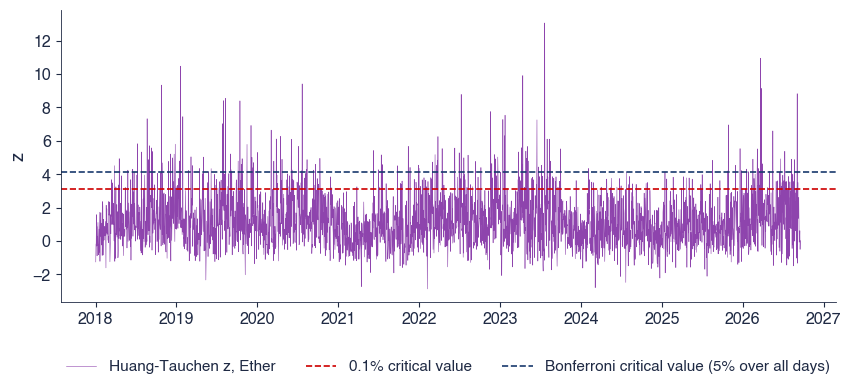

{'T': 3165, 'n_jump': 355, 'share': 0.11216429699842022, 'expected': 3.165, 'zb': 4.161650423937115, 'n_bonf': 137, 'jv_share': 0.023206751102458578, 'first': '2018-01-02', 'last': '2026-09-18', 'top': [('2023-07-22', 13.06011955659265), ('2026-03-23', 10.949641478994005), ('2019-01-19', 10.475871529012597)], 'mean_z': 1.1855549973010453}


In [17]:
# Solution
print(b1_eth_jumps(save_it=False))

**Interpretation of the result.** Too many rejections for the null, but a small jump share: frequent small "jumps" partly reflect intraday seasonality and zero returns.

## B2 [Solved]: HAR for the DAX

**Question.** How persistent is DAX realised variance, and does HAR beat the random walk out of sample?

1. HAR by OLS with Newey–West standard errors.
2. HAR, log-HAR and random-walk forecasts; average QLIKE.
3. Diebold–Mariano tests.
4. Interpretation.

**Report:** four coefficients with s.e., two statistics, three average losses, two DM statistics, one sentence.

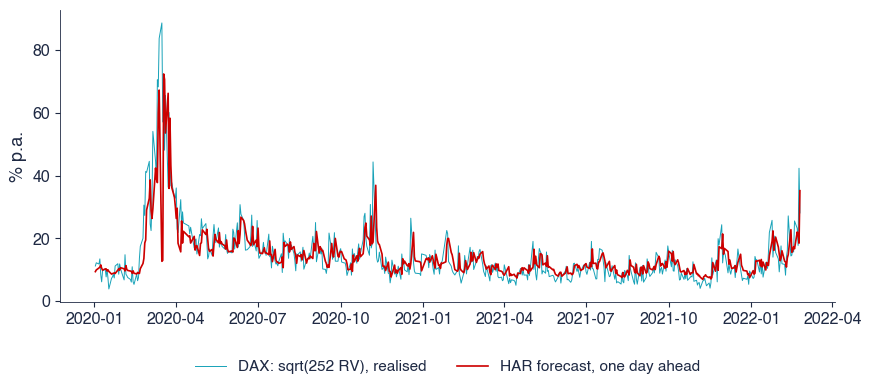

{'T': 5589, 'b': [0.15108956900676035, 0.4140160462931367, 0.27895956127663785, 0.21015311878796455], 'se': [0.04434258140759922, 0.06876271798770289, 0.10670683989358189, 0.06009593968306254], 'r2': 0.5608392048028317, 'sum': 0.9031287263577392, 'T_oos': 4589, 'q_har': 0.1862656987706539, 'q_rw': 0.22803982584542137, 'q_log': 0.1597261225030593, 'dm_rw': 2.7497832248143097, 'dm_log': -2.0944455637730894, 'first': '2000-02-01', 'last': '2022-02-24', 'first_oos': '2004-01-22'}


In [18]:
# Solution
print(b2_har_dax(save_it=False))

**Interpretation of the result.** The daily component has the largest weight; HAR beats the random walk and is beaten by log-HAR.

## B3 [Proposed]: HARQ for Ether out of sample

**Question.** Does the HARQ gain hold for Ether? Model: B2 and A8.

1. HAR and HARQ with the insanity filter; QLIKE and MSE ratios with DM.
2. Raw forecasts outside the range; negative ones.
3. A floor instead of the filter.
4. Interpretation.

**Report:** four ratios with DM statistics, two counts, one sentence.

In [ ]:
# Your code here


## B4 [Solved]: QML for EUR/RON

**Question.** How persistent is EUR/RON volatility, and how much do the standard errors matter?

1. GARCH(1,1) by Gaussian QML: Hessian and Bollerslev–Wooldridge standard errors.
2. Kurtosis of the standardised residuals.
3. GARCH-t by ML.
4. Interpretation.

**Report:** a table of three parameters with two s.e. each, one kurtosis, one log-likelihood gain, one sentence.

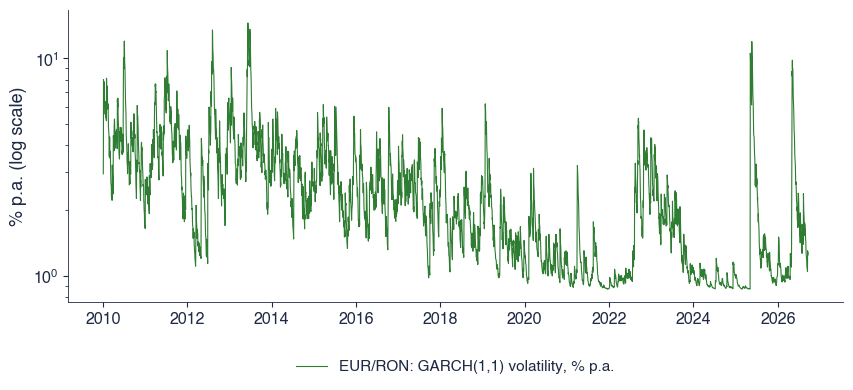

{'T': 4207, 'theta': [0.0004944312586644233, 0.16641264458330446, 0.8334178969942678], 'se_h': [4.196421328140866e-05, 0.014770737998485559, 0.01191682195038705], 'se_bw': [0.0002672599885691989, 0.040032202686523764, 0.02688907696257133], 'kurt': 61.80715989563822, 'nu': 7.939934929970466, 'll': np.float64(2574.4055502720007), 'll_t': np.float64(3435.3893124380447), 'pers': 0.9998305415775723, 'first': '2010-01-05', 'last': '2026-09-18', 'kurt_raw': 15.40573878014975}


In [20]:
# Solution
print(b4_eurron(save_it=False))

**Interpretation of the result.** Almost integrated volatility with rare bursts; the extreme kurtosis left after filtering says one variance equation is not enough for a managed float.

## B5 [Proposed]: GARCH-MIDAS for the BET

**Question.** Does Romanian industrial production drive the long-run volatility of the BET? Model: B4.

1. GARCH-MIDAS with $K = 24$ monthly lags; $\hat\theta$ and $\hat w$ with sandwich s.e.
2. The variance ratio.
3. BIC against GARCH(1,1).
4. Interpretation.

**Report:** two estimates with s.e., one ratio, two BIC values, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: Bitcoin before and after the spot ETFs

**Question.** Did Bitcoin volatility become more equity-like after 11 January 2024? Model: B1–B3.

1. A five-line pre-registration.
2. Volatility, jump-day share, jump share, HAR persistence and correlation with the S&P 500, before and after.
3. Which differences could you attribute to the ETFs?
4. Interpretation and a project plan.

**Report:** a five-line plan, a table of two rows, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) Gaussian QML is inconsistent when returns are fat-tailed; use Student-t ML instead;
- (b) sampling prices as often as possible always makes realised variance more precise;
- (c) on a day without jumps, bipower variation equals realised variance;
- (d) HAR is a long-memory model;
- (e) MSE on log variances is a robust loss for comparing forecasts against squared returns;
- (f) in DCC the target S is the unconditional correlation of the standardised residuals, so the estimator is consistent;
- (g) in Realized GARCH the realised measure may be a biased and noisy signal of the conditional variance.

1. For each statement, say whether it is correct; if not, give the correct statement and a number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
